# NOTEBOOK: Ridge Linear Regression

 Goal: Implement and evaluate Ridge Linear Regression

## Setup

In [15]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_target_relationships
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import SKLearnRidgeRegression
from src.models.unsupervised import SKLearnPCA

from src.models.supervised.model_selection import (
    k_fold_cross_validation, 
    plot_cross_validation_results,
    grid_search_cv,
    plot_grid_search_results
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading & Exploration

DATA ANALYSIS

Dataset shape: 1338 rows × 6 columns

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
dtype: object

✓ No missing values found

Numerical columns (3):
['age', 'bmi', 'children']

Categorical columns (3):
['sex', 'smoker', 'region']

Numerical features statistics:
               age          bmi     children
count  1338.000000  1338.000000  1338.000000
mean     39.207025    30.663397     1.094918
std      14.049960     6.098187     1.205493
min      18.000000    15.960000     0.000000
25%      27.000000    26.296250     0.000000
50%      39.000000    30.400000     1.000000
75%      51.000000    34.693750     2.000000
max      64.000000    53.130000     5.000000


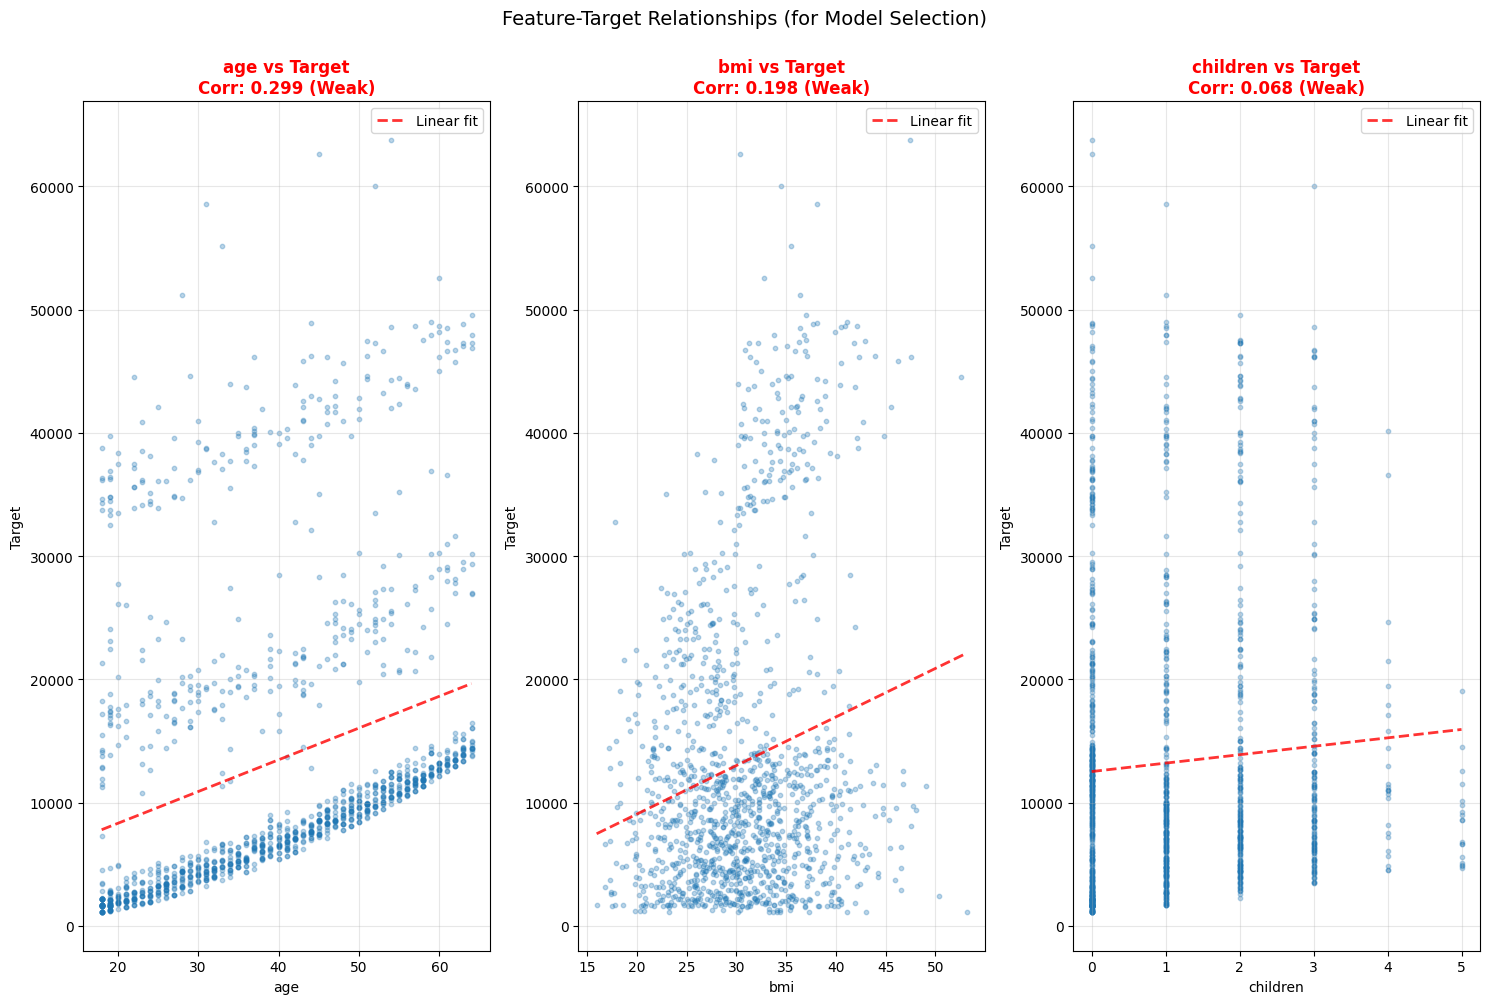

In [ ]:
# Load data
# Quick EDA: shape, dtypes, missing values, class distribution
# Feature/target split

X, y = data_loader.load_ames_housing()

analyze_data(X, show_stats=True)
plot_feature_target_relationships(X, y)

## Preprocess Data

In [17]:


# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=True, encode_categorical=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")
print(f"\nFeature names after preprocessing:")
print(preprocessor.get_feature_names())


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 3 columns
   Nominal categorical: 3 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 3 nominal columns...
   → Created 8 one-hot features

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 3 features

Final shape: 1070 rows × 11 features

Training set: (1070, 11)
Test set: (268, 11)

Feature names after preprocessing:
['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


## Baseline Model

In [18]:
model = SKLearnRidgeRegression()
model.fit(X_train_proc, y_train)

baseline_score = model.score(X_test_proc, y_test)
print("✓ Model trained successfully")

✓ Model trained successfully


## Baseline Evaluation & Diagnostics


MODEL EVALUATION
R² Score: 0.7834
RMSE: 5798.2988
MAE: 4186.9131

💡 Good performance (R² ≥ 0.75)


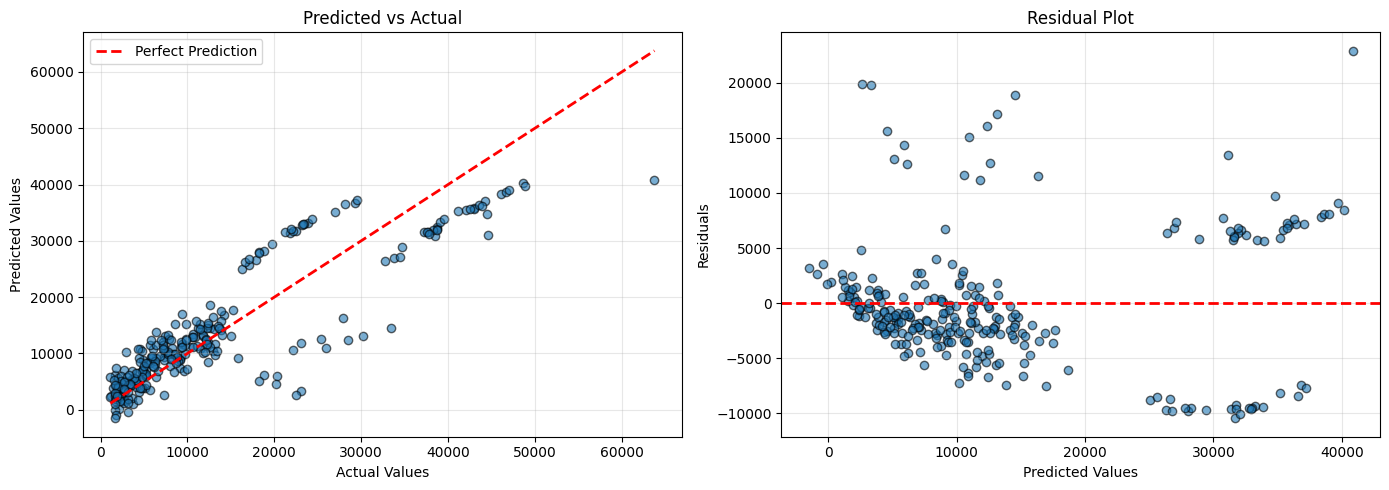


💡 How to interpret:
   • Predicted vs Actual: Points close to red line = good predictions
   • Residual Plot: Random scatter around zero = good model fit
   • Patterns in residuals = model is missing something


In [19]:
y_pred = model.predict(X_test_proc)
r2 = model.score(X_test_proc, y_test)
rmse = np.sqrt(model.mean_squared_error(X_test_proc, y_test))
mae = model.mean_absolute_error(X_test_proc, y_test)

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

if r2 >= 0.90:
    print("\n💡 Excellent performance (R² ≥ 0.90)")
elif r2 >= 0.75:
    print("\n💡 Good performance (R² ≥ 0.75)")
elif r2 >= 0.60:
    print("\n💡 Moderate performance (R² ≥ 0.60)")
else:
    print("\n💡 Room for improvement (R² < 0.60)")

# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\n💡 How to interpret:")
print("   • Predicted vs Actual: Points close to red line = good predictions")
print("   • Residual Plot: Random scatter around zero = good model fit")
print("   • Patterns in residuals = model is missing something")

## K-Fold Cross-Validation for Robust Evaluation


K-FOLD CROSS-VALIDATION
K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1070

Fold 1/5: r2=0.7267 (train: 856, test: 214)
Fold 2/5: r2=0.7065 (train: 856, test: 214)
Fold 3/5: r2=0.7747 (train: 856, test: 214)
Fold 4/5: r2=0.7092 (train: 856, test: 214)
Fold 5/5: r2=0.7771 (train: 856, test: 214)

CROSS-VALIDATION RESULTS
Mean r2: 0.7389 ± 0.0311
Min r2:  0.7065
Max r2:  0.7771


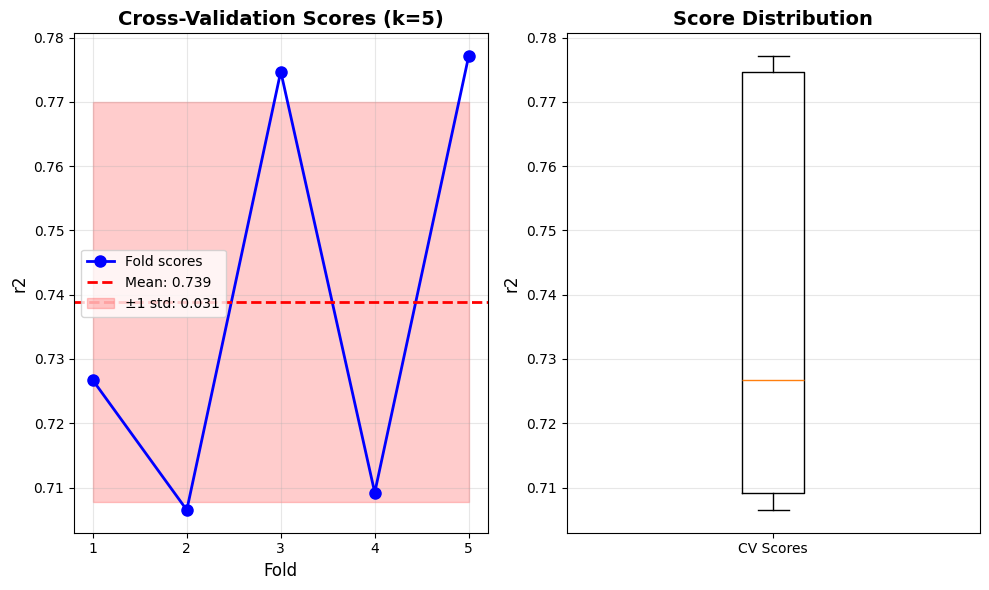


💡 Cross-validation provides more reliable estimate:
   Single test split: 0.7834
   5-fold CV: 0.7389 ± 0.0311


In [20]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation
cv_baseline = k_fold_cross_validation(
    model=model,  # Use same model as before
    X=X_train_proc,
    y=y_train,
    k=5,
    scoring='r2'
)

# Visualize
plot_cross_validation_results(cv_baseline)

print(f"\n💡 Cross-validation provides more reliable estimate:")
print(f"   Single test split: {r2:.4f}")
print(f"   5-fold CV: {cv_baseline['mean']:.4f} ± {cv_baseline['std']:.4f}")

## Dimensionality Reduction Visualization


PCA 2D VISUALIZATION

PCA PROJECTION - REGRESSION
Target range: [1121.87, 62592.87]
💡 Color intensity = target value magnitude
   • Darker colors = lower values
   • Lighter colors = higher values
   Look for patterns: Do similar values cluster together?


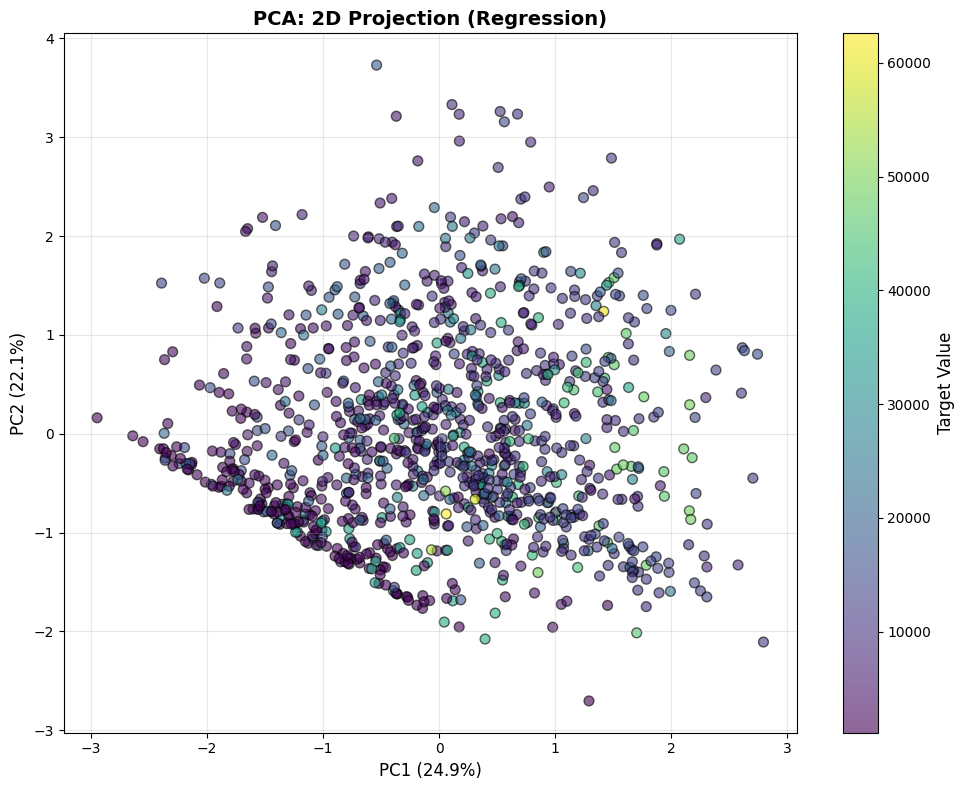


Variance explained:
  PC1: 24.9%
  PC2: 22.1%
  Total: 47.0%


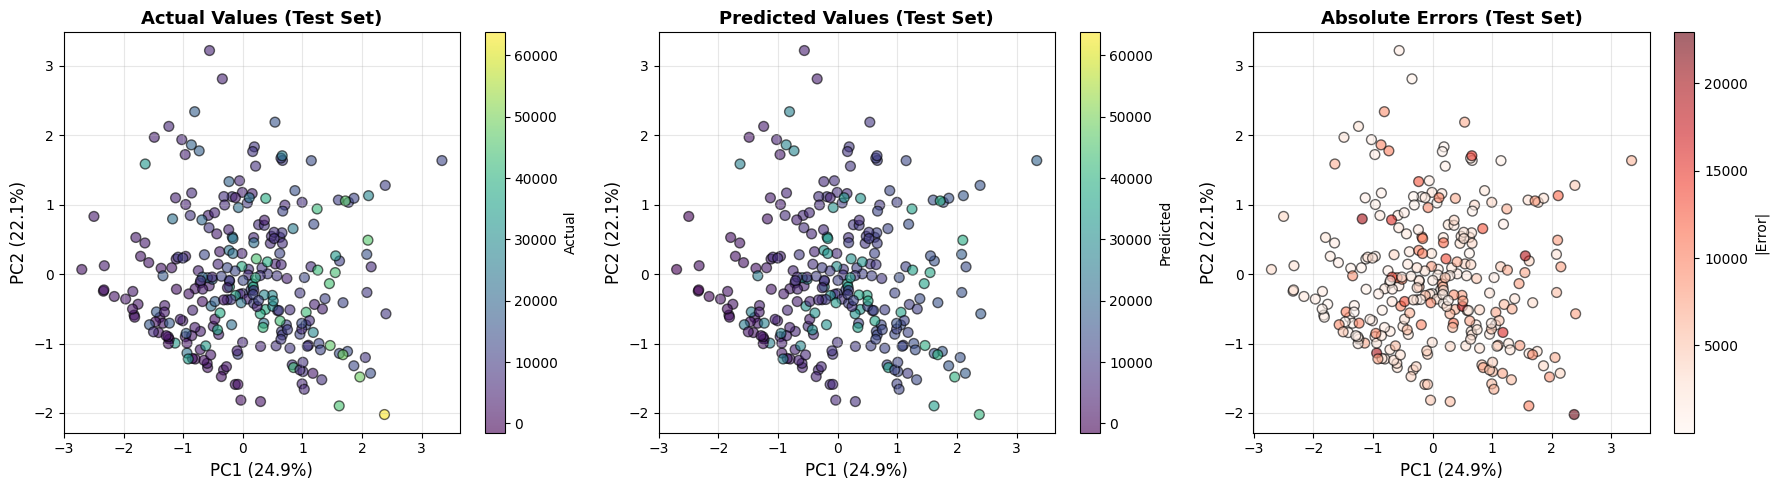


REGRESSION PROJECTION ANALYSIS

Target range: [-1520.71, 63770.43]
Mean absolute error: 4186.91
Max absolute error: 22913.79

💡 Interpretation:
   • Similar colors (left vs middle) → Good predictions
   • Different colors → Prediction errors
   • Red areas (right plot) → High error regions
   • Look for spatial patterns: Are errors clustered?


In [21]:
print("\n" + "="*70)
print("PCA 2D VISUALIZATION")
print("="*70)

pca = SKLearnPCA(n_components=2)
pca.fit(X_train_proc)
pca.plot_2d_projection(X_train_proc, y_train, task='regression')
pca.plot_regression_projection_with_predictions(
    X_test_proc, y_test, y_pred, 
    title_suffix="Test Set"
)

## Hyper-Parameter Tuning

In [22]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid based on model
param_grid = {
    # Ridge/Lasso
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_results = grid_search_cv(
    model_class=SKLearnRidgeRegression,
    param_grid=param_grid,
    X=X_train_proc,
    y=y_train,
    cv=5,
    verbose=True
)

# Visualize grid search results (if 2 parameters)
if len(param_grid) >= 2:
    param_names = list(param_grid.keys())
    plot_grid_search_results(grid_results, param_names[0], param_names[1])

print(f"\n✓ Best parameters: {grid_results['best_params']}")
print(f"✓ Best CV score: {grid_results['best_score']:.4f}")


HYPERPARAMETER TUNING
GRID SEARCH WITH CROSS-VALIDATION
Parameter grid:
  alpha: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

Total combinations to test: 6
Cross-validation folds: 5
Total fits: 30

K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1070

Fold 1/5: r2=0.7268 (train: 856, test: 214)
Fold 2/5: r2=0.7064 (train: 856, test: 214)
Fold 3/5: r2=0.7747 (train: 856, test: 214)
Fold 4/5: r2=0.7092 (train: 856, test: 214)
Fold 5/5: r2=0.7771 (train: 856, test: 214)

CROSS-VALIDATION RESULTS
Mean r2: 0.7389 ± 0.0311
Min r2:  0.7064
Max r2:  0.7771
[1/6] {'alpha': 0.001}
  → r2: 0.7389 ± 0.0311

K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1070

Fold 1/5: r2=0.7268 (train: 856, test: 214)
Fold 2/5: r2=0.7064 (train: 856, test: 214)
Fold 3/5: r2=0.7747 (train: 856, test: 214)
Fold 4/5: r2=0.7092 (train: 856, test: 214)
Fold 5/5: r2=0.7771 (train: 856, test: 214)

CROSS-VALIDATION RESULTS
Mean r2: 0.7389 ± 0.0311
Min r2:  0.7064
Max r2:  0

## Final Model Evaluation


MODEL EVALUATION
R² Score: 0.7834
RMSE: 5798.2988
MAE: 4186.9131

💡 Good performance (R² ≥ 0.75)


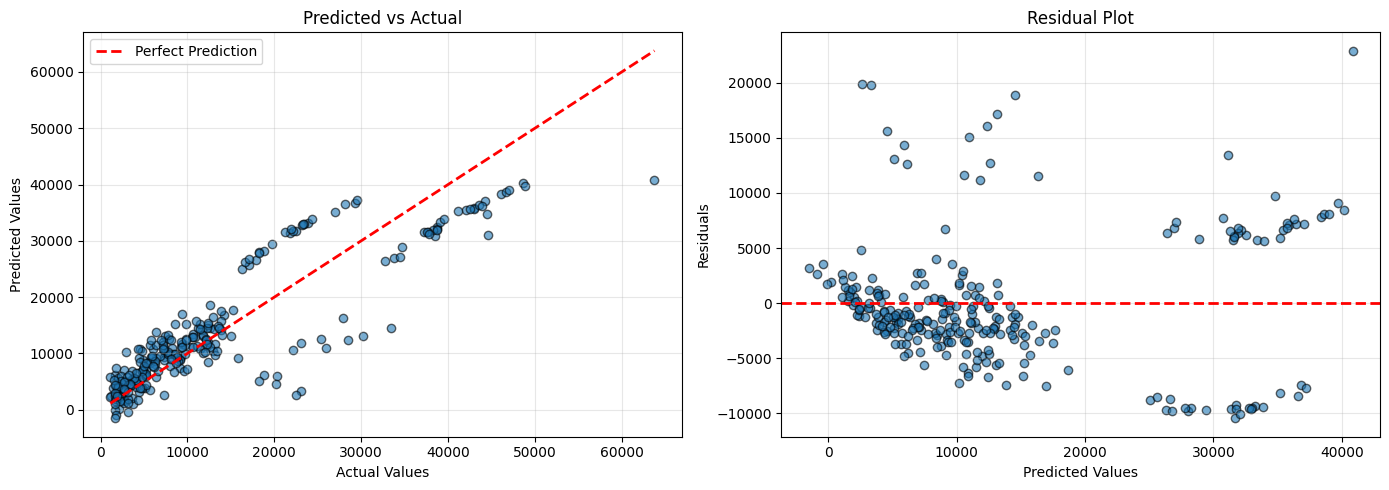


💡 How to interpret:
   • Predicted vs Actual: Points close to red line = good predictions
   • Residual Plot: Random scatter around zero = good model fit
   • Patterns in residuals = model is missing something


In [23]:
best_model = grid_results['best_model']

final_score = best_model.score(X_test_proc, y_test)

final_y_pred = best_model.predict(X_test_proc)
final_r2 = best_model.score(X_test_proc, y_test)
final_rmse = np.sqrt(best_model.mean_squared_error(X_test_proc, y_test))
final_mae = best_model.mean_absolute_error(X_test_proc, y_test)

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)
print(f"R² Score: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE: {final_mae:.4f}")

if final_r2 >= 0.90:
    print("\n💡 Excellent performance (R² ≥ 0.90)")
elif final_r2 >= 0.75:
    print("\n💡 Good performance (R² ≥ 0.75)")
elif final_r2 >= 0.60:
    print("\n💡 Moderate performance (R² ≥ 0.60)")
else:
    print("\n💡 Room for improvement (R² < 0.60)")

# Residual analysis
residuals = y_test - final_y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, final_y_pred, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(final_y_pred, residuals, alpha=0.6, edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\n💡 How to interpret:")
print("   • Predicted vs Actual: Points close to red line = good predictions")
print("   • Residual Plot: Random scatter around zero = good model fit")
print("   • Patterns in residuals = model is missing something")

## Model Comparison


MODEL COMPARISON
              Model  Accuracy       Std
0   Baseline (test)  0.783443       NaN
1     Baseline (CV)  0.738855  0.031059
2    Optimized (CV)  0.738855       NaN
3  Optimized (test)  0.783443       NaN


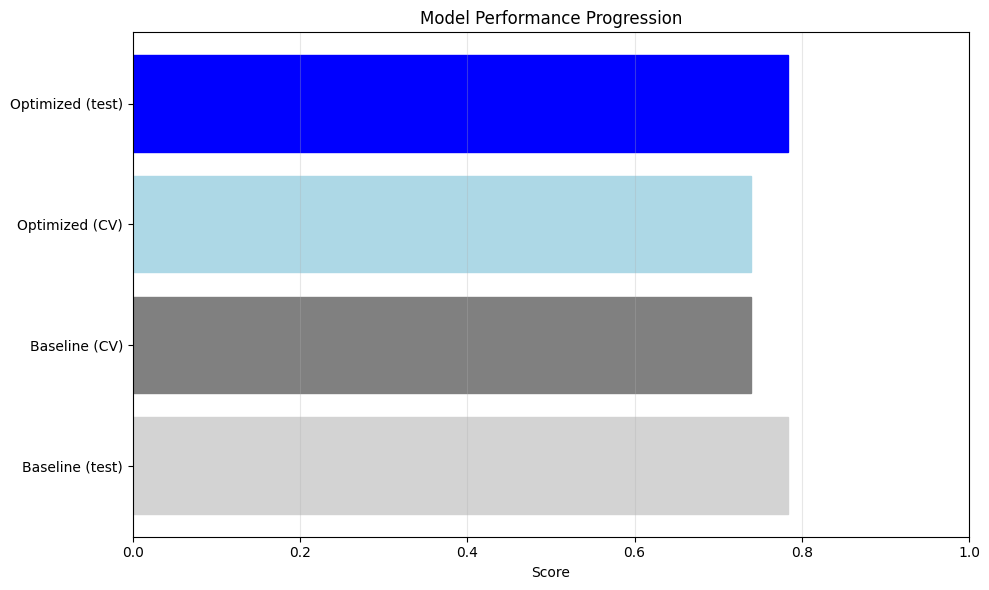


💡 Improvement from tuning: 0.00%


In [24]:
comparison_df = pd.DataFrame({
    'Model': ['Baseline (test)', 'Baseline (CV)', 'Optimized (CV)', 'Optimized (test)'],
    'Accuracy': [
        baseline_score,
        cv_baseline['mean'],
        grid_results['best_score'],
        final_score
    ],
    'Std': [None, cv_baseline['std'], None, None]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'])
bars[0].set_color('lightgray')
bars[1].set_color('gray')
bars[2].set_color('lightblue')
bars[3].set_color('blue')
plt.xlabel('Score')
plt.title('Model Performance Progression')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n💡 Improvement from tuning: {(final_score - baseline_score)*100:.2f}%")

## Feature Analysis


FEATURE IMPORTANCE (Coefficients)

Analyzing 11 coefficients


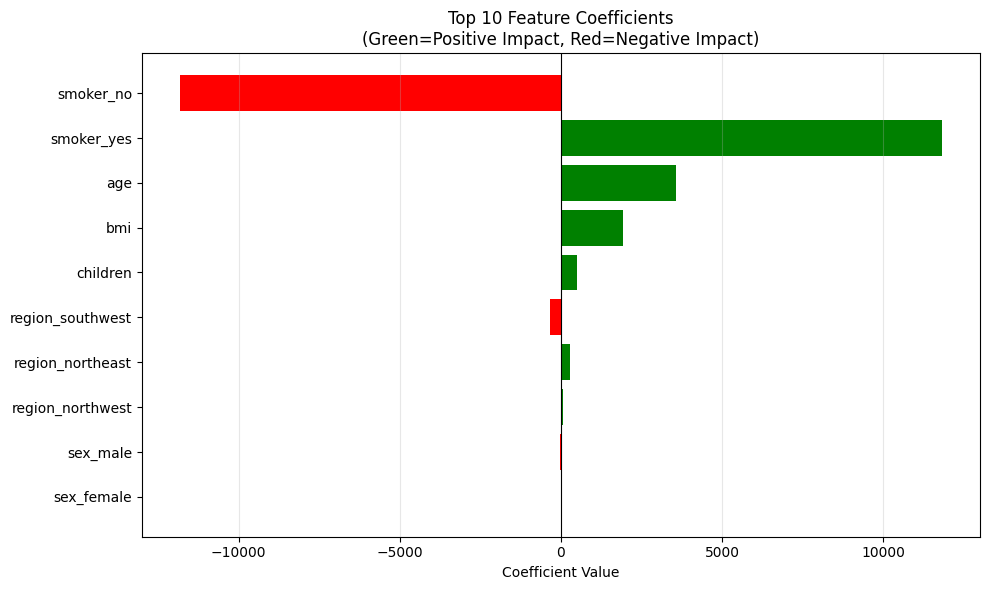


💡 Coefficient interpretation:
   • Positive: Feature increase → higher probability of class 1
   • Negative: Feature increase → lower probability of class 1
   • Larger magnitude: Stronger influence

Top 5 most important features:
  • smoker_no: -11816.6596 (decreases survival probability)
  • smoker_yes: +11816.6596 (increases survival probability)
  • age: +3583.4428 (increases survival probability)
  • bmi: +1915.7004 (increases survival probability)
  • children: +507.9634 (increases survival probability)


In [25]:
if hasattr(model, 'coef_'):
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE (Coefficients)")
    print("="*70)
    
    coefs = model.coef_
    if len(coefs.shape) > 1:
        coefs = coefs[0]
    
    # Get feature names from preprocessor
    feature_names = preprocessor.get_feature_names()
    
    print(f"\nAnalyzing {len(coefs)} coefficients")
    
    # Sort by absolute value
    abs_coefs = np.abs(coefs)
    top_n = min(10, len(coefs))
    indices = np.argsort(abs_coefs)[-top_n:]
    
    # Plot
    plt.figure(figsize=(10, 6))
    colors = ['red' if coefs[i] < 0 else 'green' for i in indices]
    plt.barh(range(len(indices)), coefs[indices], color=colors)
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Coefficient Value')
    plt.title(f'Top {top_n} Feature Coefficients\n(Green=Positive Impact, Red=Negative Impact)')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Coefficient interpretation:")
    print("   • Positive: Feature increase → higher probability of class 1")
    print("   • Negative: Feature increase → lower probability of class 1")
    print("   • Larger magnitude: Stronger influence")
    
    # Show top coefficients
    print(f"\nTop {min(5, top_n)} most important features:")
    for idx in indices[::-1][:5]:
        direction = "increases" if coefs[idx] > 0 else "decreases"
        print(f"  • {feature_names[idx]}: {coefs[idx]:+.4f} ({direction} survival probability)")

## Key Insights & Summary

In [26]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"\n✓ Baseline score: {baseline_score:.4f}")
print(f"✓ Optimized score: {final_score:.4f}")
print(f"✓ Improvement: {(final_score - baseline_score)*100:.2f}%")
print(f"\n✓ Best hyperparameters found:")
for param, value in grid_results['best_params'].items():
    print(f"   • {param}: {value}")


KEY INSIGHTS

✓ Baseline score: 0.7834
✓ Optimized score: 0.7834
✓ Improvement: 0.00%

✓ Best hyperparameters found:
   • alpha: 1.0
